<a href="https://colab.research.google.com/github/DjameelEddine/Suspicious-Network-Behavior-Detection/blob/djamel/Suspicious_Network_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

- ### Datasets Loading

In [ ]:
dataframes_list = []
file_names = [
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning-DDosAttack.pcap_ISCX.csv',
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Egress-Botnet.pcap_ISCX.csv',
    'Wednesday-WorkingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv'
]

print("Initialized an empty list for dataframes and defined the list of file names.")

In [ ]:
import kagglehub

dataset_handle = 'chethuhn/network-intrusion-dataset'
dataset_path = kagglehub.dataset_download(dataset_handle)

print(f"Dataset '{dataset_handle}' downloaded to: {dataset_path}")

- ### See available CSV files in the directory

In [ ]:
import os

# Assuming dataset_path is already defined from the previous step

print(f"Listing files in: {dataset_path}")

# Filter for CSV files
csv_files_in_dataset = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Sort the file names for consistent order
csv_files_in_dataset.sort()

print("Available CSV files:")
for f in csv_files_in_dataset:
    print(f)

# Update the file_names list with the discovered CSV files
file_names = csv_files_in_dataset

print(f"\nUpdated file_names list with {len(file_names)} CSV files.")

- ### Load the CSV files separately

In [ ]:
dataframes_list = [] # Re-initialize dataframes_list to ensure it's empty
import kagglehub
from kagglehub import KaggleDatasetAdapter

for file_name in file_names:
    print(f"\nLoading file: {file_name}")
    df_temp = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "chethuhn/network-intrusion-dataset",
        file_name
    )
    print(f"\n{'#'*30}\nShape of {file_name}: {df_temp.shape}\n{'#'*30}")
    dataframes_list.append(df_temp)

print(f"\nSuccessfully loaded {len(dataframes_list)} DataFrames.")

- ### Datasets Combination

- We check whether all datasets have the same columns

In [ ]:
# Remove possible space before/after columns' names
for df in dataframes_list:
  df.columns = df.columns.str.strip()

In [ ]:
all_same = 1
for i in range(len(dataframes_list) - 1):
  if (dataframes_list[i].columns != dataframes_list[i+1].columns).any():
    all_same = 0
    print (f'Dataframes {dataframes_list[i]} and {dataframes_list[i+1]} have different columns')

if all_same:
  print ('All datasets have the same columns')

In [ ]:
# Combine datasets into one dataframe
combined_df = pd.concat(dataframes_list, ignore_index=True)
print (f'Combined Dataframe has shape: {combined_df.shape}')

In [ ]:
combined_df.head()

### Constant features removal

In [ ]:
# Get max lengths for dynamic alignment
max_col_len = combined_df.columns.str.len().max()
max_type_len = combined_df.dtypes.astype(str).str.len().max()

for c in combined_df.columns:
    print(f"`{c:<{max_col_len}}` type: {str(combined_df[c].dtype):<{max_type_len}} nulls: {combined_df[c].isna().sum():>6} unique: {combined_df[c].nunique():>6}")

- Some Features have a single value (zero variance) provding no distinction between instances.
- We'll drop these features as they don't provide any information gain.

In [ ]:
# get features with a single value
single_value_features = [c for c in combined_df.columns if len(combined_df[c].unique()) == 1]

# keep only variant features
var_df = combined_df.drop(columns=single_value_features) # var_df == means ==> variant dataframe
var_df.shape

- 8 constant features were removed

### Handling duplicates

In [ ]:
# Show duplicate rows with counts
duplicates_df = var_df[var_df.duplicated()]
print (f' duplicates are {duplicates_df.shape[0] * 100 / var_df.shape[0]:.2f}% of `var_df` dataset')

 duplicates are 10.89% of `var_df` dataset


- Identical rows may appear in both the training and testing sets, which might illude the model to **Memorize** instances instead of learning patterns.
- To handle this, Create a new dataframe having only unique rows with a new `count` column to indicate the number of appearances of each row in the original dataframe

In [ ]:
# Show unique rows with counts
count_df = var_df.groupby(list(var_df.columns), dropna=False).size().reset_index(name='count')
count_df.shape, count_df.duplicated().any()

((2522362, 72), np.False_)

- All duplicates have been removed

In [ ]:
count_df.sort_values('count', ascending=False).head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,count
902009,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,9329
902010,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,6814
902199,80,4,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,6613
901729,80,1,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,5846
902200,80,4,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,4314


- It's noticeable that `DoS Hulk` attack is dominant when it comes to duplicate flows.

### Univariate Analysis

**Outliers handling, null detection, and label imbalancy**

- **Features** will be treated based on their **distribution** regarding `null values` and `outliers`.

 - In fact, **All** skewed features will be treated similar to `Flow Bytes/s`, that is, impute `inf` values if existing by the max (or min), apply the `log(1 + x)` transform to the feature, and imputing `NaN` values with the `median`

 - Normally distributed features' `NaN` values will be imputed using the `mean`.

- See all columns having null values

In [ ]:
for c in count_df.columns:
  if count_df[c].isna().any():
    print (f'Feature `{c}` has {count_df[c].isna().sum()} null values.')

Feature `Flow Bytes/s` has 353 null values.


In [ ]:
count_df['Flow Bytes/s'].describe()

,Flow Bytes/s
count,2.522362e+06
mean,7.786376e+00
std,4.597246e+00
min,0.000000e+00
25%,4.791329e+00
50%,8.222423e+00
75%,1.158674e+01
max,2.145130e+01


- Notice that `Flow Bytes/s` is the only feature with null values

- We'll try to infer the **reason** behind these null values for `Flow Bytes/s` in the *Bivariate Analsysis* part

- Also, We'll add a feature `Flow Bytes/s_was_missing` to indicate missingness after imputation.

- **Outliers Handling**

- Notice that only two non-null binary features are not skewed, therefore, all features except these two, will be treated as follows:
  1. Replace `inf` with the Max of the feature
  2. Apply Log Transformation
  3. Impute remaining NaNs with the Median (of the log values)

- The remaining features will be treated as follows:
  1. Impute NaNs with the mean.

- In the next cells, we'll consider many example features, like `Flow Bytes/s` representing the skewed features, showing **before/after outliers** are handled, and **NaNs** also, using the steps defined above.

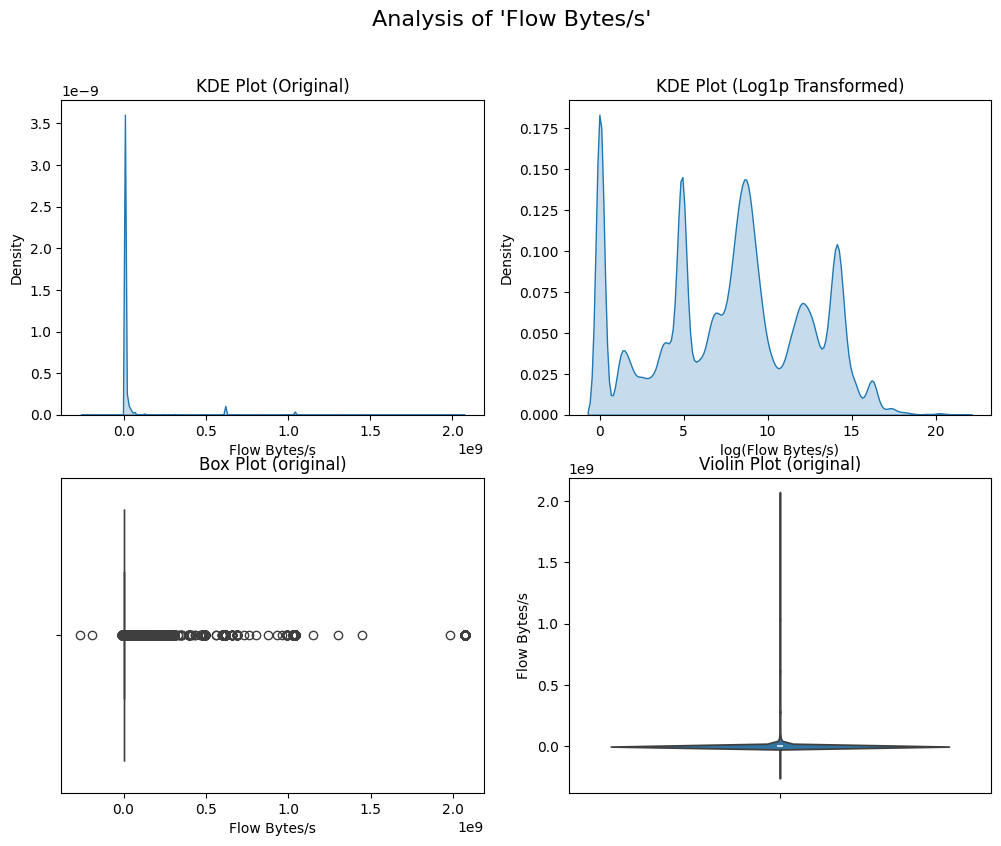

In [ ]:
import numpy as np

column_name = 'Flow Bytes/s'

data = count_df[column_name].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(f'Analysis of \'{column_name}\'', fontsize=16)

# Plot 1: KDE plot for original data
sns.kdeplot(data, ax=axes[0, 0], fill=True)
axes[0, 0].set_title('KDE Plot (Original)')
axes[0, 0].set_xlabel(column_name)
axes[0, 0].set_ylabel('Density')

# Plot 2: KDE plot after log transformation
data_log = data.apply(lambda x: np.log1p(x) if x >= 0 else np.nan).dropna()
sns.kdeplot(data_log, ax=axes[0, 1], fill=True)
axes[0, 1].set_title('KDE Plot (Log1p Transformed)')
axes[0, 1].set_xlabel(f'log({column_name})')
axes[0, 1].set_ylabel('Density')

# Plot 3: Box plot
sns.boxplot(x=data, ax=axes[1, 0])
axes[1, 0].set_title('Box Plot (original)')
axes[1, 0].set_xlabel(column_name)

# Plot 4: Violin plot (replacing the histogram)
sns.violinplot(y=data, ax=axes[1, 1], inner='box')  # or inner='quartile'
axes[1, 1].set_title('Violin Plot (original)')
axes[1, 1].set_ylabel(column_name)

plt.show()

- `Flow Bytes/s` was heavily right-skewed as shown in the original KDE plot, unlike the KDE of the log-transformation of this feature, which shows a multimodel distribution.

- This feature will be replaced by its *`log1p`
 transformation*, but first, inconsistent values (like `inf`) need to be addressed.

In [ ]:
max_finite = count_df[count_df['Flow Bytes/s'] != np.inf]['Flow Bytes/s'].max()
count_df['Flow Bytes/s'] = count_df['Flow Bytes/s'].replace(np.inf, max_finite)

print(f"Inf values present: {(log_df['Flow Bytes/s'] == float('inf')).any()}")

Inf values present: False


- Applying `logp1` transformation

In [ ]:
log_df = count_df.copy()
log_df['Flow Bytes/s'] = np.log1p(count_df['Flow Bytes/s'])
log_df['Flow Bytes/s'].describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Flow Bytes/s
count,2.521931e+06
mean,7.786301e+00
std,4.597635e+00
min,0.000000e+00
25%,4.791274e+00
50%,8.222423e+00
75%,1.158985e+01
max,2.145130e+01


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_11724/4198330611.py:2: SyntaxWarning: invalid escape sequence '\ '
  fig.suptitle(f'Analysis of \'{column_name}\ after log1p transform', fontsize=16)


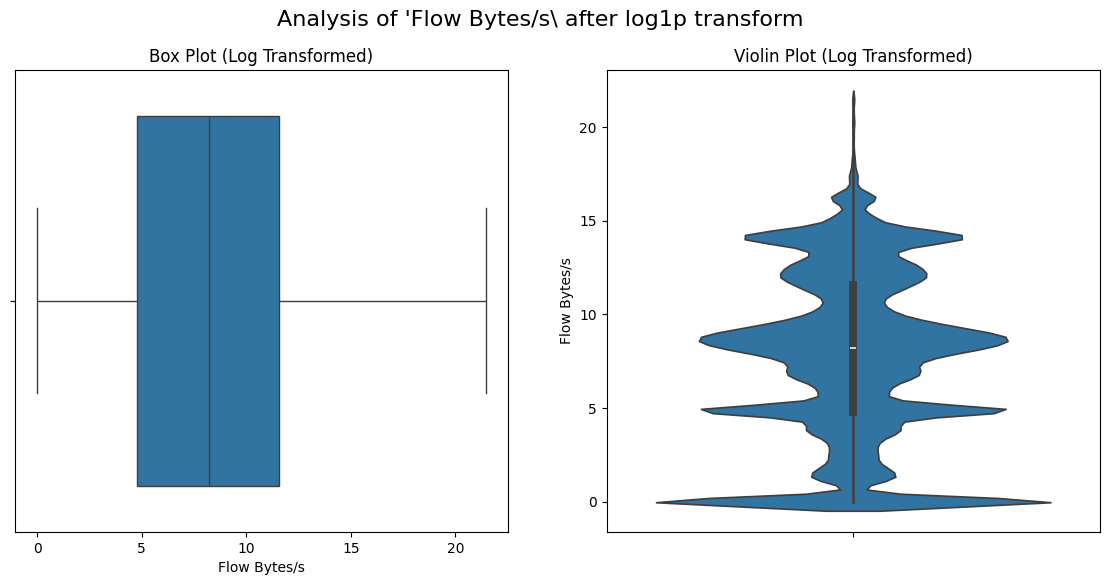

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

column_name = 'Flow Bytes/s'

fig.suptitle(f'Analysis of \'{column_name}\ after log1p transform', fontsize=16)

data = log_df['Flow Bytes/s'].dropna()

# Plot 3: Box plot
sns.boxplot(x=data, ax=axes[0])
axes[0].set_title('Box Plot (Log Transformed)')
axes[0].set_xlabel('Flow Bytes/s_log')

# Plot 4: Violin plot (replacing the histogram)
sns.violinplot(y=data, ax=axes[1], inner='box')  # or inner='quartile'
axes[1].set_title('Violin Plot (Log Transformed)')
axes[1].set_ylabel('Flow Bytes/s_log')

plt.show()

- Most, if not all, outliers have disappeared in the `Flow Bytes/s` feature.
- Now we fill the null values of `Flow Bytes/s` with the median for safety and risk avoidance.

In [ ]:
log_df['Flow Bytes/s'] = log_df['Flow Bytes/s'].fillna(log_df['Flow Bytes/s'].median())
log_df['Flow Bytes/s'].isna().any()

np.False_

In [ ]:
print(f"{'Feature':<30} | {'Nulls':<10} | {'Inf':<10} | {'Unique Values':<10}")
print("-" * 70)

for col in log_df.columns:
    null_count = log_df[col].isna().sum()
    inf_count = (log_df[col] == float('inf')).sum() + (log_df[col] == float('-inf')).sum()
    unique_count = log_df[col].nunique()
    print(f"{col:<30} | {null_count:<10} | {inf_count:<10} | {unique_count:<10}")

Feature                        | Nulls      | Inf        | Unique Values
----------------------------------------------------------------------
Destination Port               | 0          | 0          | 53805     
Flow Duration                  | 0          | 0          | 1050899   
Total Fwd Packets              | 0          | 0          | 1432      
Total Backward Packets         | 0          | 0          | 1747      
Total Length of Fwd Packets    | 0          | 0          | 17928     
Total Length of Bwd Packets    | 0          | 0          | 64698     
Fwd Packet Length Max          | 0          | 0          | 5279      
Fwd Packet Length Min          | 0          | 0          | 384       
Fwd Packet Length Mean         | 0          | 0          | 99716     
Fwd Packet Length Std          | 0          | 0          | 253909    
Bwd Packet Length Max          | 0          | 0          | 4838      
Bwd Packet Length Min          | 0          | 0          | 583       
Bwd Packet Lengt

- Notice that `Flow Packets/s` also have `inf` values that need to be replaced with the maximum of its finite values

In [ ]:
max_finite = log_df[log_df['Flow Packets/s'] != np.inf]['Flow Packets/s'].max()
log_df['Flow Packets/s'] = log_df['Flow Packets/s'].replace(np.inf, max_finite)

print(f"Inf values present: {(count_df['Flow Packets/s'] == float('inf')).any()}")

Inf values present: False


- Get a list a skewed features, and a list of normally distributed features

In [ ]:
from scipy.stats import skew

highly_skewed = []
normal_ish = []

for col in count_df.columns:
  # pandas function to check numeric types
    if pd.api.types.is_numeric_dtype(count_df[col]):
        data = count_df[col].dropna().values
        if len(data) > 0:
            skew_val = skew(data)
            if abs(skew_val) > 1.0:
                highly_skewed.append(col)
            else:
                normal_ish.append(col)

print (f'There are {len(highly_skewed)} highly skewed features')
print (f'There are {len(normal_ish)} normally dsitributed features')

There are 68 highly skewed features
There are 3 normally dsitributed features


In [ ]:
for c in normal_ish:
  print (f'{c} has {len(var_df[c].unique())} uniques, which are: {var_df[c].unique()}')

Flow Bytes/s has 1593909 uniques, which are: [4.00000000e+06 1.10091743e+05 2.30769231e+05 ... 8.19494024e+03
 4.27222055e+02 4.36069476e+03]
PSH Flag Count has 2 uniques, which are: [0 1]
ACK Flag Count has 2 uniques, which are: [1 0]


- Notice that `Flow Bytes/s` became normally distributed after transformation and imputation, and so the case with all the skewed features
- Next, In order to handle the outliers the remanining features, we apply the same steps that we've done to `Flow Bytes/s` to all the remanining descriptive features.
- And check whether their ourtliers are now gone or still.
- As for `NaN` values, it has been shown that none remain, same for `inf`.

In [ ]:
for col in highly_skewed:

    count_df[col + '_log'] = np.log1p(count_df[col])

# Check skewness after transform
print("Skewness after log transform:")
for col in highly_skewed:
    original_skew = skew(count_df[col].dropna())
    transformed_skew = skew(count_df[col + '_log'].dropna())
    print(f"{col}: {original_skew:.2f} -> {transformed_skew:.2f}")

# Simple outlier check (IQR method)
print("\nOutliers after transform:")
for col in highly_skewed:
    log_col = col + '_log'
    Q1 = count_df[log_col].quantile(0.25)
    Q3 = count_df[log_col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((count_df[log_col] < (Q1 - 1.5 * IQR)) | (count_df[log_col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers")

- **values' proportions of the label feature (imbalancy)**

### Workflow:
- Pandas custom data manipulation is used just to see relations between features after doing manual manipulation (like removing outliers or applying transformations)
- It shows how the later-on defined imputer will work on the features.
- It doesn't necessarily include all features, but only ones that seem interesting (have nulls, many outlier, very relevant to the project).
- Sickit-Learn's pipelines are used for training, testing and production, reflecting the previously analyzed behavior in the `Pandas` step.

- Now, in the univariate analysis part, I need to:
  1. determine some interesting features, plot some plots, do the transformation (follow the steps of treatment above).
  2. Show how features change after treatment, using plots, `.describe()`, etc.
  3. extract some insights (already mostly done, it's about saying features are skewed, how outliers were handled, duplicates, etc.)


- In the Multivariate analysis:
  1. Infer the `null` and `inf` values for `Flow Bytes/s`, and handle them manually (pandas).
  2. Plot the heatmap showing correlation between features.
  3. Remove correlated descriptive features, and emphasis on the highly correlated with the `Label` feature.
  4. reduce the dimensionality using feature selection algorithms.
  5. Extract some insights.

- Next, split the data, Handle imbalancy for `Label`, create pipeline, train many models, compare them and choose the best, with some insights finally.

- Pro-tip: Use a Log-Scale on your y-axis for the Label count plot. It allows you to see the "Web Attack - Brute Force" (rare) and "Benign" (common) on the same chart without the small ones disappearing.

- The Inf "Leak": When you "Infer" the null and inf values manually in Pandas for the heatmap, remember that the correlation coefficient ($r$) is very sensitive to outliers. Your heatmap will look much cleaner after the Log-transform than before it.


The "Label" Trap (Step 3)
When checking correlation with the Label, remember that Label is categorical (Benign, Hulk, etc.).

Standard Pearson correlation doesn't work well with text labels.

The Fix: Label-encode them temporarily or use ANOVA (F-test) to see which numeric features vary significantly across different attack types.


One Critical Addition to the Pipeline phase:
When you create the pipeline, make sure the Scaling happens after the Feature Selection.

Custom Imputer (Max/Log/Median)

Scaler (RobustScaler)

Feature Selector (e.g., SelectKBest)

Classifier (XGBoost/RandomForest)

- I organized the workflow between null values, inf, and outliers handling.
- I need to run the transformation logic on remaining features.
- See the imbalancy of the target, and see how to handle it.
- in the analysis part (with pandas), use the transformed features only, and if needed, go check the original ones (for correlation, etc.).
- therefore, create a new dataframe for the transformed features.